# Exploratory Data Analysis

## Importing Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("EDA environment ready.")

EDA environment ready.


## Project Paths

In [2]:
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

print("Processed data directory:")
print(PROCESSED_DIR)

Processed data directory:
e:\ML + Datasets + Projects\Projects\TransOrg-AgentIQ-Datathon\data\processed


## Reading Clean Datasets along with Assigning Appropriate Data Types

In [3]:
transactions = pd.read_csv(
    PROCESSED_DIR / "upi_transactions_clean.csv",
    dtype={
        "txn_id": "string",
        "user_id": "string",
        "merchant_id": "string",
        "utr": "string",
        "mcc": "string",
        "status": "string"
    },
    parse_dates=["timestamp"]
)

kyc = pd.read_csv(
    PROCESSED_DIR / "kyc_clean.csv",
    dtype={
        "user_id": "string",
        "full_name": "string",
        "pan": "string",
        "aadhaar": "string",
        "city": "string",
        "state": "string",
        "occupation": "string",
        "kyc_status": "string",
        "risk_segment": "string"
    },
    parse_dates=[
        "date_of_birth",
        "signup_timestamp"
    ]
)

merchants = pd.read_csv(
    PROCESSED_DIR / "merchants_clean.csv",
    dtype={
        "merchant_id": "string",
        "merchant_name": "string",
        "mcc": "string",
        "merchant_category": "string",
        "business_type": "string",
        "city": "string",
        "state": "string",
        "settlement_account": "string",
        "merchant_status": "string"
    },
    parse_dates=["onboarding_date"]
)

chargebacks = pd.read_csv(
    PROCESSED_DIR / "chargebacks_clean.csv",
    dtype={
        "complaint_id": "string",
        "txn_id": "string",
        "user_id": "string",
        "merchant_id": "string",
        "reason_code": "string",
        "resolution_status": "string",
        "severity": "string",
        "channel": "string",
        "complaint_text": "string"
    },
    parse_dates=[
        "transaction_timestamp",
        "reported_timestamp",
        "bank_response_timestamp"
    ]
)

## Inspecting Shape of Datasets

In [4]:
print("Transactions :", transactions.shape)
print("KYC          :", kyc.shape)
print("Merchants    :", merchants.shape)
print("Chargebacks  :", chargebacks.shape)

Transactions : (20000, 8)
KYC          : (36122, 12)
Merchants    : (6198, 11)
Chargebacks  : (2800, 15)


## Displaying Basic Infromation

In [5]:
display(transactions.info())
display(kyc.info())
display(merchants.info())
display(chargebacks.info())

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   txn_id       20000 non-null  string        
 1   timestamp    20000 non-null  datetime64[us]
 2   user_id      20000 non-null  string        
 3   merchant_id  20000 non-null  string        
 4   amount       19580 non-null  float64       
 5   utr          19000 non-null  string        
 6   mcc          17128 non-null  string        
 7   status       20000 non-null  string        
dtypes: datetime64[us](1), float64(1), string(6)
memory usage: 1.2 MB


None

<class 'pandas.DataFrame'>
RangeIndex: 36122 entries, 0 to 36121
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           36122 non-null  string        
 1   full_name         36122 non-null  string        
 2   pan               31608 non-null  string        
 3   aadhaar           27348 non-null  string        
 4   date_of_birth     30790 non-null  datetime64[us]
 5   city              36122 non-null  string        
 6   state             36122 non-null  string        
 7   monthly_income    29987 non-null  float64       
 8   occupation        36122 non-null  string        
 9   signup_timestamp  33236 non-null  datetime64[us]
 10  kyc_status        36122 non-null  string        
 11  risk_segment      36122 non-null  string        
dtypes: datetime64[us](2), float64(1), string(9)
memory usage: 3.3 MB


None

<class 'pandas.DataFrame'>
RangeIndex: 6198 entries, 0 to 6197
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   merchant_id               6198 non-null   string        
 1   merchant_name             6198 non-null   string        
 2   mcc                       5506 non-null   string        
 3   merchant_category         6198 non-null   string        
 4   business_type             6198 non-null   string        
 5   city                      6198 non-null   string        
 6   state                     6198 non-null   string        
 7   onboarding_date           5699 non-null   datetime64[us]
 8   settlement_account        3753 non-null   string        
 9   merchant_status           6198 non-null   string        
 10  declared_avg_ticket_size  5326 non-null   float64       
dtypes: datetime64[us](1), float64(1), string(9)
memory usage: 532.8 KB


None

<class 'pandas.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   complaint_id                 2800 non-null   string        
 1   txn_id                       2723 non-null   string        
 2   user_id                      2800 non-null   string        
 3   merchant_id                  2800 non-null   string        
 4   transaction_timestamp        2570 non-null   datetime64[us]
 5   reported_timestamp           2597 non-null   datetime64[us]
 6   disputed_amount              2401 non-null   float64       
 7   reason_code                  2800 non-null   string        
 8   complaint_text               2800 non-null   string        
 9   resolution_status            2800 non-null   string        
 10  bank_response_timestamp      2099 non-null   datetime64[us]
 11  severity                     2800 non-null   string   

None

### Transaction Summary

In [6]:
transaction_summary = transactions.groupby("status").agg(
    transaction_count=("txn_id", "count"),
    total_amount=("amount", "sum"),
    average_amount=("amount", "mean")
).reset_index()

transaction_summary

,status,transaction_count,total_amount,average_amount
0,FAILED,1955,2.353859e+07,12343.257913
1,PENDING,992,1.170803e+07,12032.920462
2,SUCCESS,17053,2.092560e+08,12530.296504


## Transactions Dataset EDA

### Transactions Status Chart

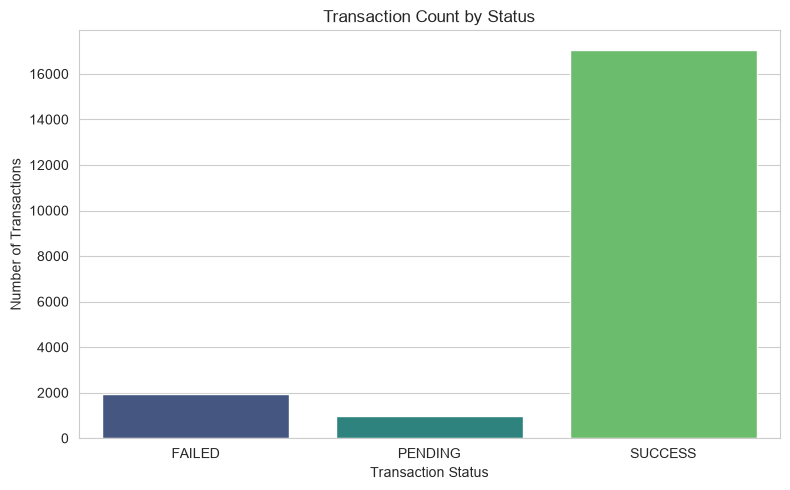

In [7]:
sns.set_style("whitegrid")
plt.figure(figsize=(8, 5))

sns.barplot(
    data=transaction_summary,
    x="status",
    y="transaction_count",
    palette="viridis"
)

plt.title("Transaction Count by Status")
plt.xlabel("Transaction Status")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

### Transaction Amount Distribution

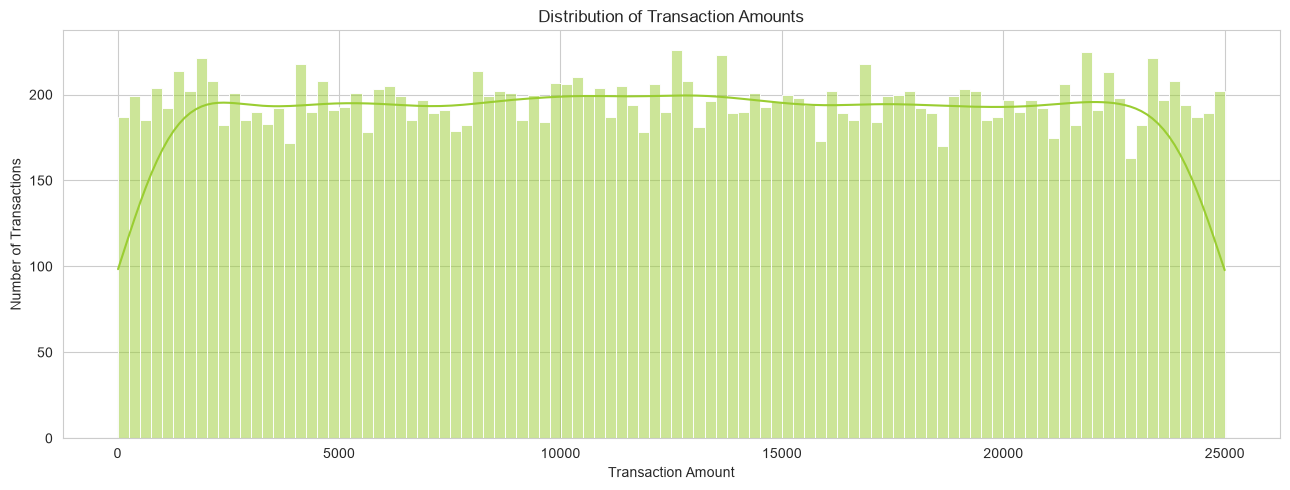

In [8]:
plt.figure(figsize=(13, 5))

sns.histplot(
    data=transactions,
    x="amount",
    bins=100,
    kde=True,
    color="yellowgreen",
)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

### Daily Transaction Volume

In [9]:
daily_transactions = (
    transactions
    .dropna(subset=["timestamp"])
    .set_index("timestamp")
    .resample("D")
    .agg(
        transaction_count=("txn_id", "count"),
        total_amount=("amount", "sum")
    )
    .reset_index()
)

daily_transactions

,timestamp,transaction_count,total_amount
0,2026-01-01,215,2539351.17
1,2026-01-02,198,2425740.24
2,2026-01-03,219,2643768.01
3,2026-01-04,180,2316530.69
4,2026-01-05,165,1878437.77
...,...,...,...
332,2026-11-29,0,0.00
333,2026-11-30,0,0.00
334,2026-12-01,45,542180.37
335,2026-12-02,49,635588.61


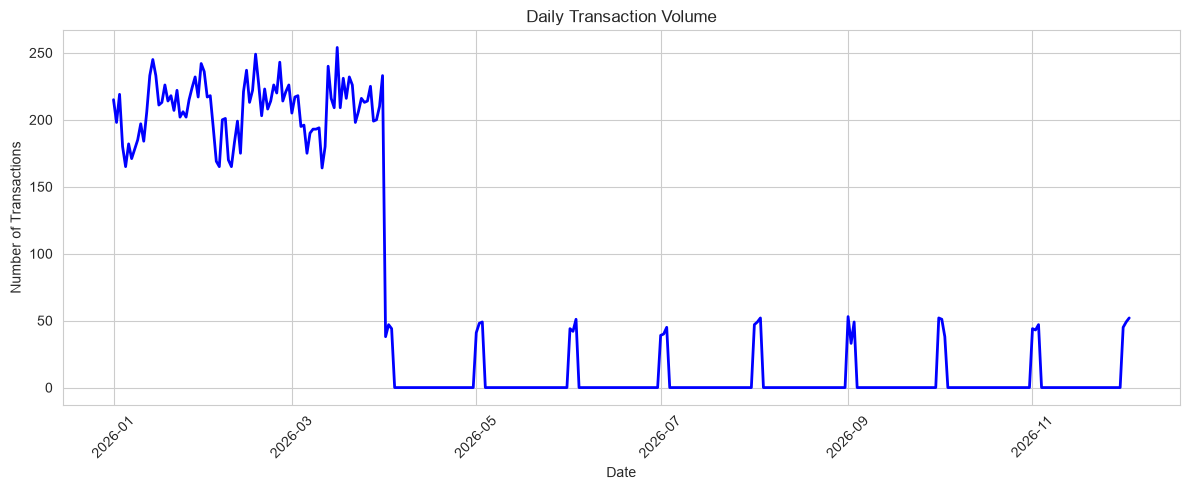

In [10]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_transactions["timestamp"],
    daily_transactions["transaction_count"],
    color="blue",
    linewidth=2,
)

plt.title("Daily Transaction Volume")
plt.xlabel("Date")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Daily Transaction Value

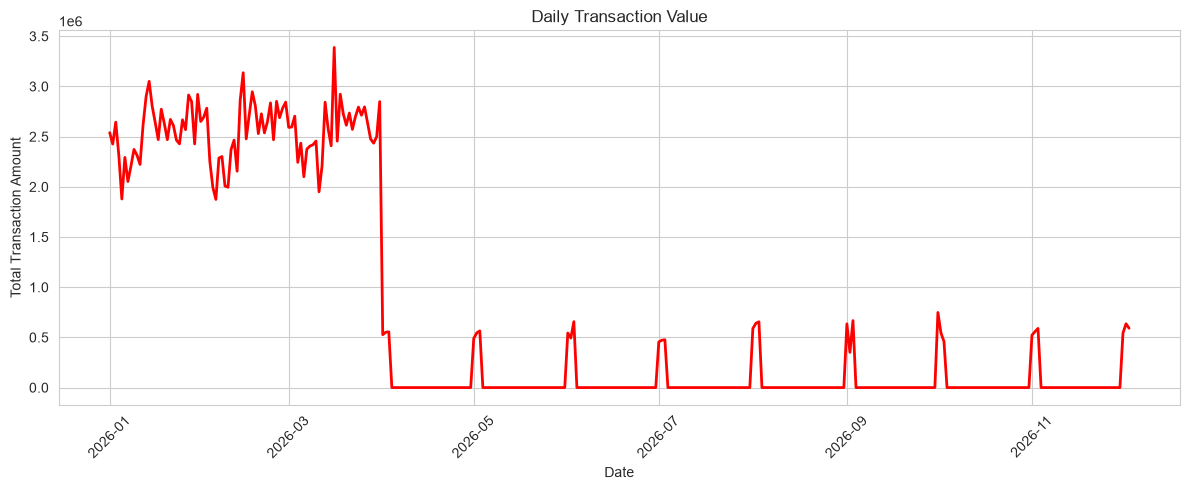

In [11]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_transactions["timestamp"],
    daily_transactions["total_amount"],
    color="red",
    linewidth=2
)

plt.title("Daily Transaction Value")
plt.xlabel("Date")
plt.ylabel("Total Transaction Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Merchant & Category EDA

### Join transactions with merchant information

In [12]:

# Create a one-row-per-merchant analytical lookup.
# This prevents repeated merchant master records from inflating transaction counts.

def most_common_value(series):
    values = series.dropna()

    if values.empty:
        return pd.NA

    return values.mode().iloc[0]


merchant_lookup = (
    merchants
    .groupby("merchant_id")
    .agg(
        merchant_name=("merchant_name", most_common_value),
        merchant_category=("merchant_category", most_common_value),
        business_type=("business_type", most_common_value),
        merchant_status=("merchant_status", most_common_value)
    )
    .reset_index()
)

transaction_merchant = transactions.merge(
    merchant_lookup,
    on="merchant_id",
    how="left",
    validate="many_to_one"
)

print("Transaction rows :", len(transaction_merchant))
print(
    "Matched merchants :",
    transaction_merchant["merchant_category"].notna().sum()
)
print(
    "Unmatched merchants :",
    transaction_merchant["merchant_category"].isna().sum()
)


Transaction rows : 20000
Matched merchants : 9631
Unmatched merchants : 10369


### Merchant Master Consistency for EDA

In [13]:
merchant_consistency = (
    merchants
    .groupby("merchant_id")
    .agg(
        master_rows=("merchant_id", "size"),
        category_count=("merchant_category", "nunique"),
        category=("merchant_category", "first"),
        merchant_name_count=("merchant_name", "nunique"),
        business_type_count=("business_type", "nunique"),
        status_count=("merchant_status", "nunique")
    )
    .reset_index()
)

merchant_consistency["category_conflict"] = (merchant_consistency["category_count"] > 1)

merchant_consistency["name_conflict"] = (merchant_consistency["merchant_name_count"] > 1)

merchant_consistency["business_type_conflict"] = (merchant_consistency["business_type_count"] > 1)

merchant_consistency["status_conflict"] = (merchant_consistency["status_count"] > 1)

merchant_consistency.head(10)

,merchant_id,master_rows,category_count,category,merchant_name_count,business_type_count,status_count,category_conflict,name_conflict,business_type_conflict,status_conflict
0,MCH1001,1,1,Grocery,1,1,1,False,False,False,False
1,MCH1002,1,1,Food Services,1,1,1,False,False,False,False
2,MCH1003,1,1,Clothing,1,1,1,False,False,False,False
3,MCH1004,1,1,Travel,1,1,1,False,False,False,False
4,MCH1005,1,1,Medical,1,1,1,False,False,False,False
5,MCH1007,2,2,Food Services,2,2,2,True,True,True,True
6,MCH1009,1,1,Transport,1,1,1,False,False,False,False
7,MCH1010,1,1,Grocery,1,1,1,False,False,False,False
8,MCH1011,2,1,Grocery,1,1,2,False,False,False,True
9,MCH1014,2,2,Food Services,2,1,1,True,True,False,False


In [14]:
print("Unique merchant IDs :", merchant_consistency["merchant_id"].nunique())

print(
    "Merchant IDs with repeated master rows :",
    (merchant_consistency["master_rows"] > 1).sum()
)

print(
    "Merchant IDs with category conflicts :",
    merchant_consistency["category_conflict"].sum()
)

print(
    "Merchant IDs with name conflicts :",
    merchant_consistency["name_conflict"].sum()
)

print(
    "Merchant IDs with business type conflicts :",
    merchant_consistency["business_type_conflict"].sum()
)

print(
    "Merchant IDs with status conflicts :",
    merchant_consistency["status_conflict"].sum()
)

Unique merchant IDs : 4343
Merchant IDs with repeated master rows : 1407
Merchant IDs with category conflicts : 1214
Merchant IDs with name conflicts : 1310
Merchant IDs with business type conflicts : 1039
Merchant IDs with status conflicts : 521


### Category summary

In [15]:
category_summary = (
    transaction_merchant
    .groupby("merchant_category", dropna=False)
    .agg(
        transaction_count=("txn_id", "count"),
        total_amount=("amount", "sum"),
        average_amount=("amount", "mean")
    )
    .reset_index()
    .sort_values("transaction_count", ascending=False)
)

category_summary

,merchant_category,transaction_count,total_amount,average_amount
12,<NA>,10369,1.267726e+08,12488.680710
1,Clothing,1276,1.557171e+07,12427.539816
0,Books & Stationery,1206,1.477250e+07,12540.324491
3,Food Services,964,1.170132e+07,12343.163745
4,Grocery,947,1.166558e+07,12543.633194
5,Hotel & Lodging,929,1.109916e+07,12250.727174
2,Department Store,910,1.127647e+07,12599.404480
7,Other,815,9.856613e+06,12336.186433
6,Medical,807,9.820074e+06,12493.733015
9,Telecom,766,9.363568e+06,12484.756787


### Transaction Count by Category

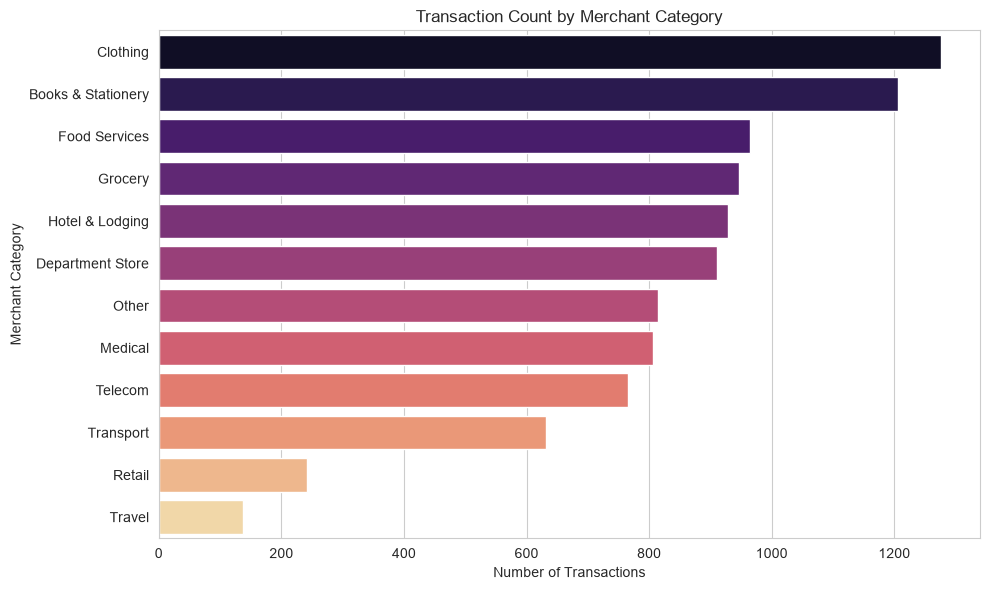

In [16]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_summary,
    y="merchant_category",
    x="transaction_count",
    palette="magma",
)

plt.title("Transaction Count by Merchant Category")
plt.xlabel("Number of Transactions")
plt.ylabel("Merchant Category")
plt.tight_layout()
plt.show()

### Transaction Value by Category

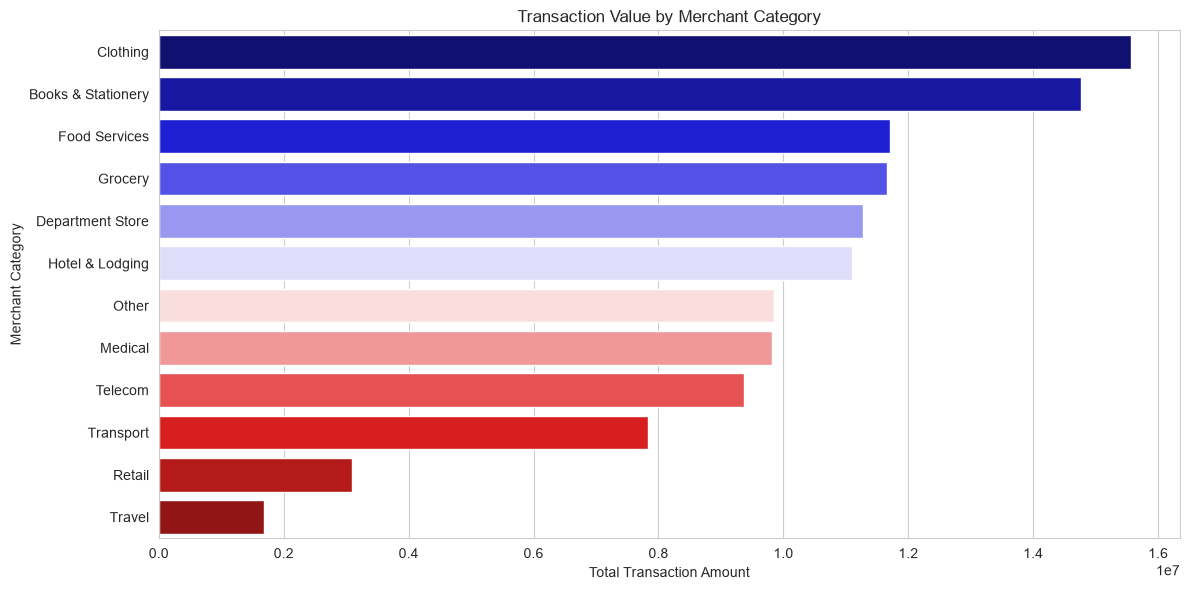

In [17]:
category_value = category_summary.sort_values(
    "total_amount",
    ascending=False
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=category_value,
    y="merchant_category",
    x="total_amount",
    palette="seismic"
)

plt.title("Transaction Value by Merchant Category")
plt.xlabel("Total Transaction Amount")
plt.ylabel("Merchant Category")
plt.tight_layout()
plt.show()

## Transaction Status by Merchant Category

In [18]:
category_status = (
    transaction_merchant
    .groupby(
        ["merchant_category", "status"],
        dropna=False
    )
    .size()
    .reset_index(name="transaction_count")
)

category_status

,merchant_category,status,transaction_count
0,Books & Stationery,FAILED,107
1,Books & Stationery,PENDING,69
2,Books & Stationery,SUCCESS,1030
3,Clothing,FAILED,118
4,Clothing,PENDING,58
5,Clothing,SUCCESS,1100
6,Department Store,FAILED,96
7,Department Store,PENDING,45
8,Department Store,SUCCESS,769
9,Food Services,FAILED,75


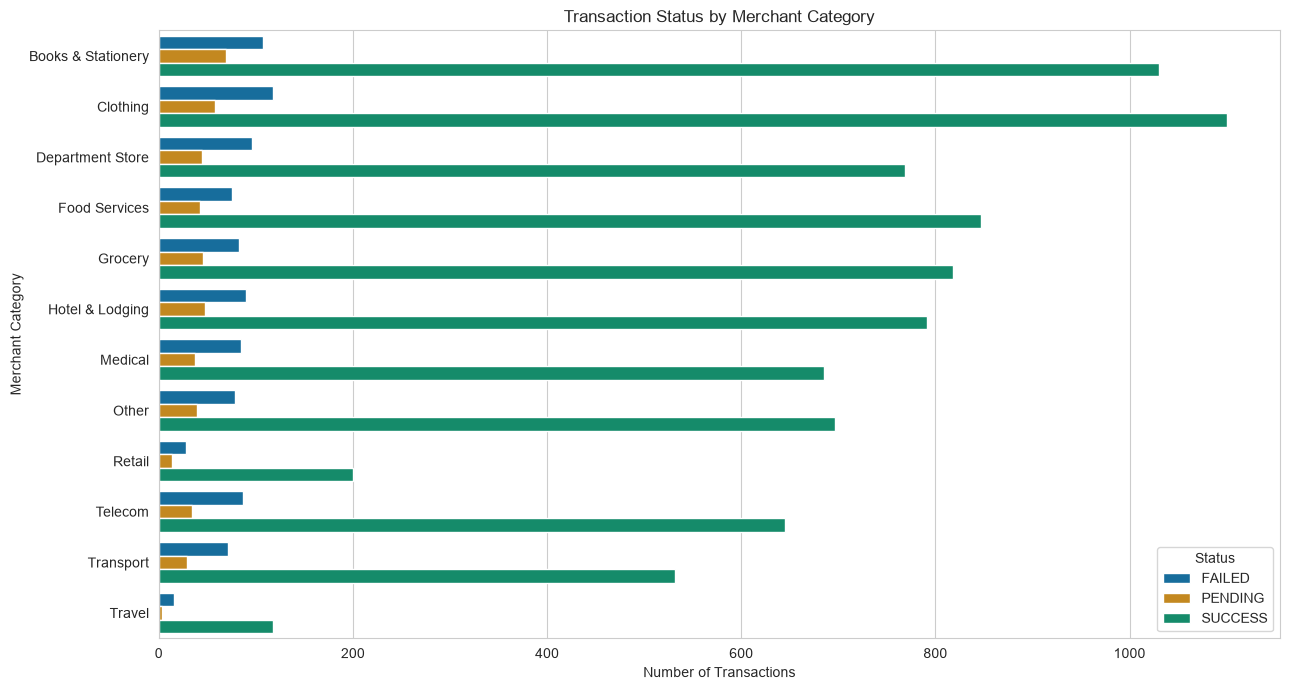

In [19]:
plt.figure(figsize=(13, 7))

sns.barplot(
    data=category_status,
    y="merchant_category",
    x="transaction_count",
    palette="colorblind",
    hue="status"
)

plt.title("Transaction Status by Merchant Category")
plt.xlabel("Number of Transactions")
plt.ylabel("Merchant Category")
plt.legend(title="Status")
plt.tight_layout()
plt.show()

## Chargeback and Dispute Analysis

### Basic chargeback summary

In [20]:
chargeback_summary = pd.DataFrame({
    "metric": [
        "Total chargebacks",
        "Total disputed amount",
        "Average disputed amount",
        "Median disputed amount"
    ],
    "value": [
        chargebacks["complaint_id"].nunique(),
        chargebacks["disputed_amount"].sum(),
        chargebacks["disputed_amount"].mean(),
        chargebacks["disputed_amount"].median()
    ]
})

chargeback_summary

,metric,value
0,Total chargebacks,2.800000e+03
1,Total disputed amount,7.395785e+06
2,Average disputed amount,3.080294e+03
3,Median disputed amount,1.823800e+03


### Chargebacks by Reason

In [21]:
chargeback_reason = (
    chargebacks
    .groupby("reason_code")
    .agg(
        chargeback_count=("complaint_id", "count"),
        disputed_amount=("disputed_amount", "sum")
    )
    .reset_index()
    .sort_values("chargeback_count", ascending=False)
)

chargeback_reason

,reason_code,chargeback_count,disputed_amount
4,SERVICE_NOT_PROVIDED,704,1894914.99
1,CUSTOMER_DISPUTE,376,1015446.95
5,UNAUTHORIZED_TRANSACTION,371,1041806.67
2,DUPLICATE_DEBIT,352,917237.47
0,ACCOUNT_TAKEOVER,344,868213.83
3,FRAUD_SUSPECTED,327,879692.38
6,WRONG_AMOUNT,326,778472.88


### Chargeback Count by Reason

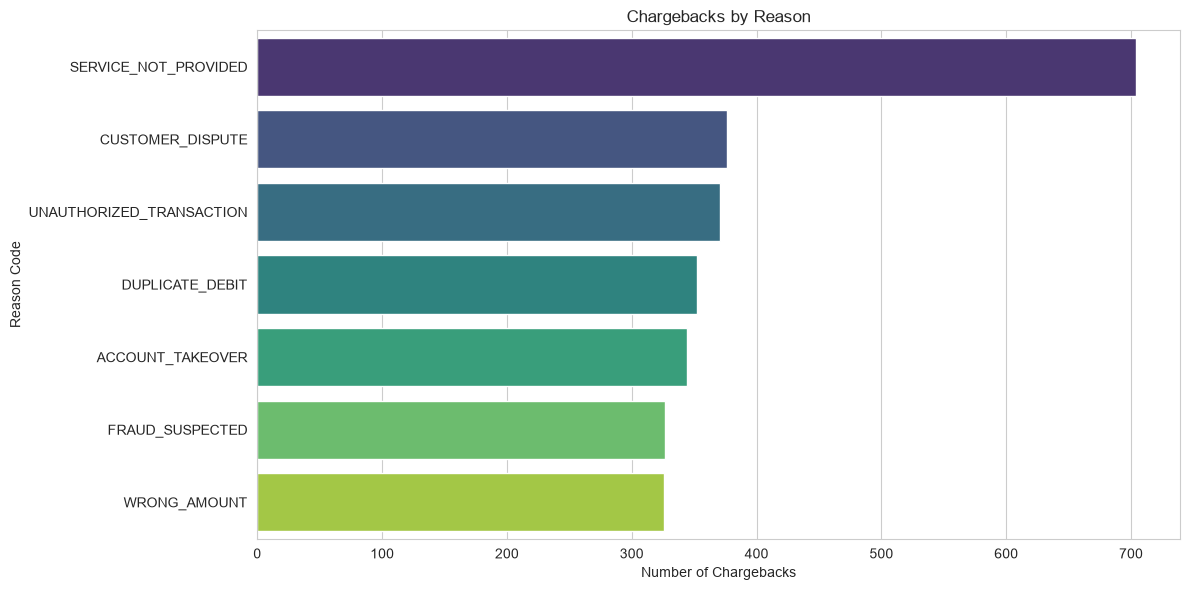

In [22]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=chargeback_reason,
    y="reason_code",
    x="chargeback_count",
    palette="viridis"
)

plt.title("Chargebacks by Reason")
plt.xlabel("Number of Chargebacks")
plt.ylabel("Reason Code")
plt.tight_layout()
plt.show()

### Chargeback by Severity

In [23]:
severity_order = [
    "LOW",
    "MEDIUM",
    "HIGH",
    "CRITICAL"
]

chargeback_severity = (
    chargebacks
    .groupby("severity")
    .agg(
        chargeback_count=("complaint_id", "count"),
        disputed_amount=("disputed_amount", "sum")
    )
    .reindex(severity_order)
    .reset_index()
)

chargeback_severity

,severity,chargeback_count,disputed_amount
0,LOW,959,2687852.97
1,MEDIUM,1024,2494358.85
2,HIGH,604,1579601.60
3,CRITICAL,213,633971.75


### Chart for Severity

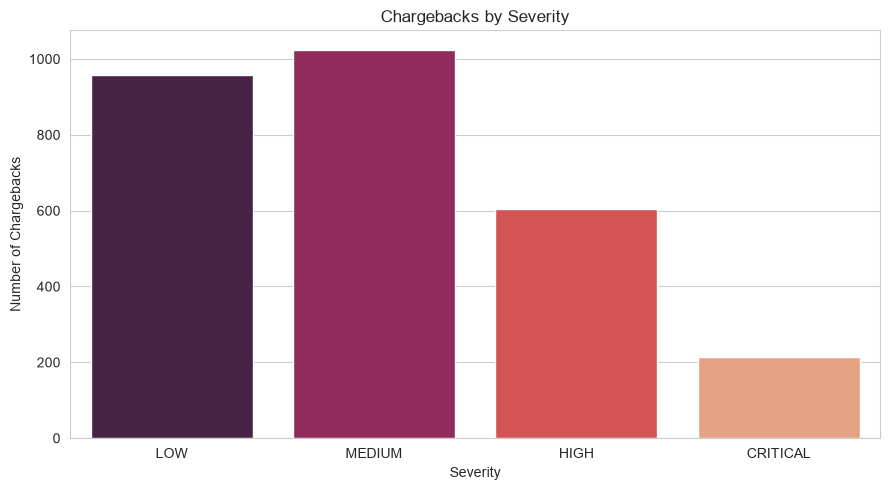

In [24]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=chargeback_severity,
    x="severity",
    y="chargeback_count",
    palette="rocket"
)

plt.title("Chargebacks by Severity")
plt.xlabel("Severity")
plt.ylabel("Number of Chargebacks")
plt.tight_layout()
plt.show()

## Chargeback Ratio

### Transaction Counts by Category

In [25]:
category_transactions = (
    transaction_merchant
    .groupby("merchant_category", dropna=False)
    .agg(
        transaction_count=("txn_id", "count"),
        transaction_amount=("amount", "sum")
    )
    .reset_index()
)

category_transactions

,merchant_category,transaction_count,transaction_amount
0,Books & Stationery,1206,1.477250e+07
1,Clothing,1276,1.557171e+07
2,Department Store,910,1.127647e+07
3,Food Services,964,1.170132e+07
4,Grocery,947,1.166558e+07
5,Hotel & Lodging,929,1.109916e+07
6,Medical,807,9.820074e+06
7,Other,815,9.856613e+06
8,Retail,242,3.089158e+06
9,Telecom,766,9.363568e+06


### Chargebacks + merchant category

In [26]:

chargeback_merchant = chargebacks.merge(
    merchant_lookup[
        [
            "merchant_id",
            "merchant_category"
        ]
    ],
    on="merchant_id",
    how="left",
    validate="many_to_one"
)

print("Chargeback rows :", len(chargeback_merchant))
print(
    "Matched merchants :",
    chargeback_merchant["merchant_category"].notna().sum()
)
print(
    "Unmatched merchants :",
    chargeback_merchant["merchant_category"].isna().sum()
)


Chargeback rows : 2800
Matched merchants : 1299
Unmatched merchants : 1501


###  Chargeback Category Summary

In [27]:
category_chargebacks = (
    chargeback_merchant
    .groupby("merchant_category", dropna=False)
    .agg(
        chargeback_count=("complaint_id", "count"),
        disputed_amount=("disputed_amount", "sum")
    )
    .reset_index()
)

category_chargebacks

,merchant_category,chargeback_count,disputed_amount
0,Books & Stationery,156,325055.92
1,Clothing,216,533662.79
2,Department Store,99,230819.17
3,Food Services,184,459411.03
4,Grocery,93,320446.04
5,Hotel & Lodging,133,337992.75
6,Medical,136,403578.82
7,Other,79,243133.50
8,Retail,26,51582.64
9,Telecom,85,267801.18


In [28]:
category_risk = category_transactions.merge(
    category_chargebacks,
    on="merchant_category",
    how="left"
)

category_risk["chargeback_count"] = (
    category_risk["chargeback_count"]
    .fillna(0)
)

category_risk["disputed_amount"] = (
    category_risk["disputed_amount"]
    .fillna(0)
)

category_risk["chargeback_ratio"] = (
    category_risk["chargeback_count"]
    / category_risk["transaction_count"]
    * 100
)

category_risk = category_risk.sort_values(
    "chargeback_ratio",
    ascending=False
)

category_risk

,merchant_category,transaction_count,transaction_amount,chargeback_count,disputed_amount,chargeback_ratio
3,Food Services,964,1.170132e+07,184,459411.03,19.087137
1,Clothing,1276,1.557171e+07,216,533662.79,16.927900
6,Medical,807,9.820074e+06,136,403578.82,16.852540
12,<NA>,10369,1.267726e+08,1501,3975188.25,14.475841
5,Hotel & Lodging,929,1.109916e+07,133,337992.75,14.316469
10,Transport,632,7.827375e+06,82,219545.74,12.974684
0,Books & Stationery,1206,1.477250e+07,156,325055.92,12.935323
9,Telecom,766,9.363568e+06,85,267801.18,11.096606
2,Department Store,910,1.127647e+07,99,230819.17,10.879121
8,Retail,242,3.089158e+06,26,51582.64,10.743802


### Chargeback-to-Transaction Ratio

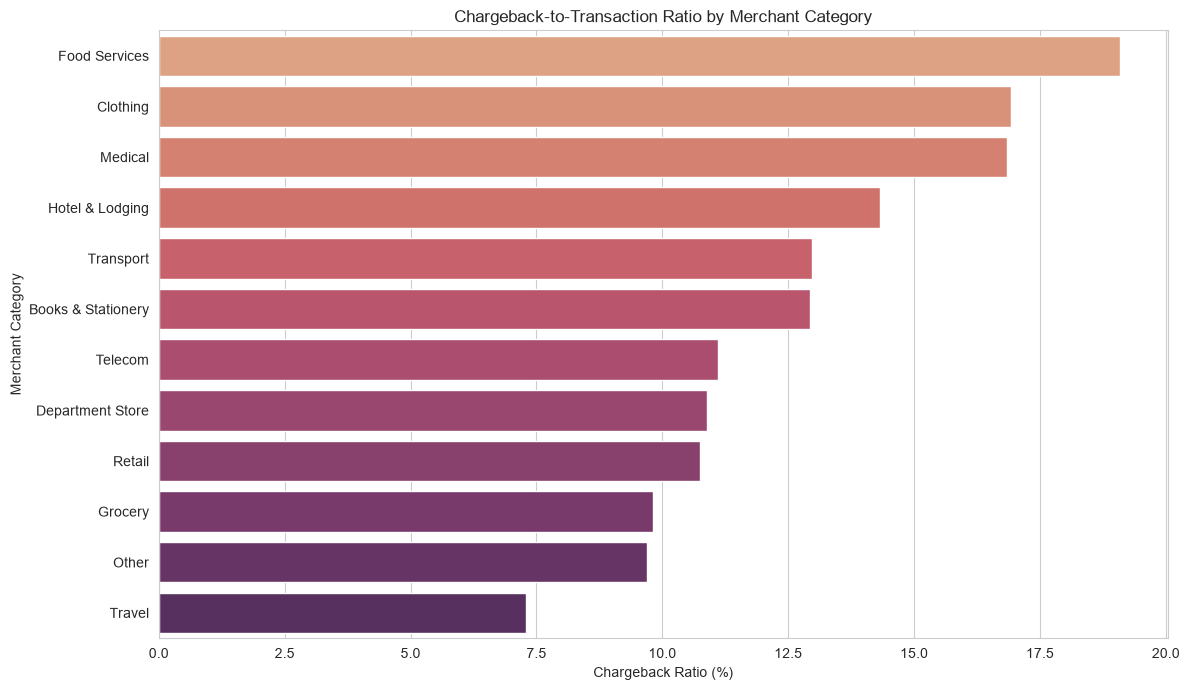

In [29]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=category_risk,
    y="merchant_category",
    x="chargeback_ratio",
    palette="flare"
)

plt.title("Chargeback-to-Transaction Ratio by Merchant Category")
plt.xlabel("Chargeback Ratio (%)")
plt.ylabel("Merchant Category")
plt.tight_layout()
plt.show()

## KYC & Risk Segment Analysis

### KYC status distribution

In [30]:
kyc_summary = (
    kyc
    .groupby("kyc_status")
    .size()
    .reset_index(name="user_count")
    .sort_values("user_count", ascending=False)
)

kyc_summary

,kyc_status,user_count
2,VERIFIED,27555
0,PENDING,5422
1,REJECTED,3145


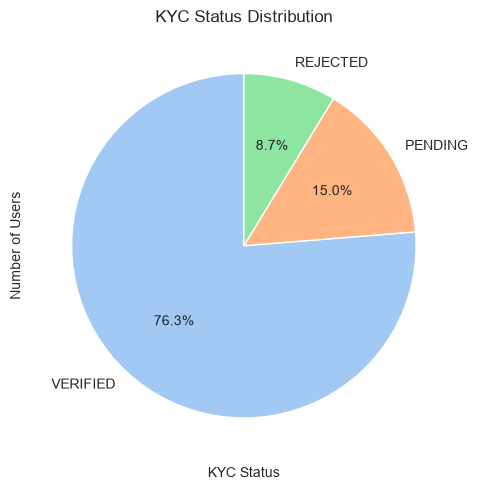

In [31]:
plt.figure(figsize=(9, 5))

plt.pie(
    data=kyc_summary,
    x="user_count",
    labels=kyc_summary["kyc_status"],
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("pastel")
)

plt.title("KYC Status Distribution")
plt.xlabel("KYC Status")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()

### Risk Segment Distribution

In [32]:
risk_summary = (
    kyc
    .groupby("risk_segment")
    .size()
    .reset_index(name="user_count")
)

risk_summary

,risk_segment,user_count
0,HIGH,3693
1,LOW,20821
2,MEDIUM,9762
3,UNKNOWN,1846


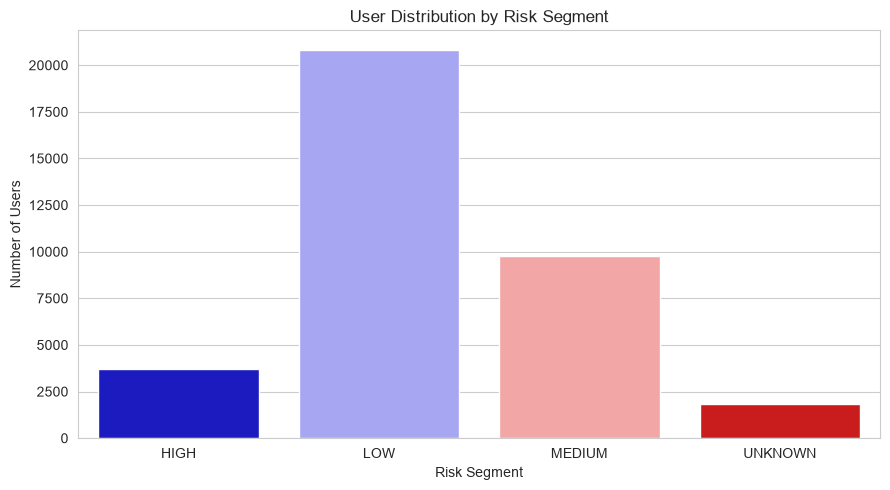

In [33]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=risk_summary,
    x="risk_segment",
    y="user_count",
    palette="seismic"
)

plt.title("User Distribution by Risk Segment")
plt.xlabel("Risk Segment")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()

### Transaction Activity by Risk Segment

In [34]:
def most_common_value(series):
    values = series.dropna()

    if values.empty:
        return pd.NA

    return values.mode().iloc[0]


kyc_lookup = (
    kyc
    .groupby("user_id")
    .agg(
        risk_segment=("risk_segment", most_common_value),
        kyc_status=("kyc_status", most_common_value),
        city=("city", most_common_value),
        state=("state", most_common_value)
    )
    .reset_index()
)

transaction_risk = transactions.merge(
    kyc_lookup,
    on="user_id",
    how="left",
    validate="many_to_one"
)

print("Transaction rows :", len(transaction_risk))

Transaction rows : 20000


### Risk-Segment Transaction Summary

In [35]:
risk_transaction_summary = (
    transaction_risk
    .groupby("risk_segment", dropna=False)
    .agg(
        transaction_count=("txn_id", "count"),
        total_amount=("amount", "sum"),
        average_amount=("amount", "mean")
    )
    .reset_index()
    .sort_values("transaction_count", ascending=False)
)

risk_transaction_summary

,risk_segment,transaction_count,total_amount,average_amount
4,<NA>,13522,1.661603e+08,12536.617362
1,LOW,3826,4.630148e+07,12393.329813
2,MEDIUM,1563,1.914928e+07,12507.696133
0,HIGH,801,9.508635e+06,12159.379795
3,UNKNOWN,288,3.382852e+06,12212.460578


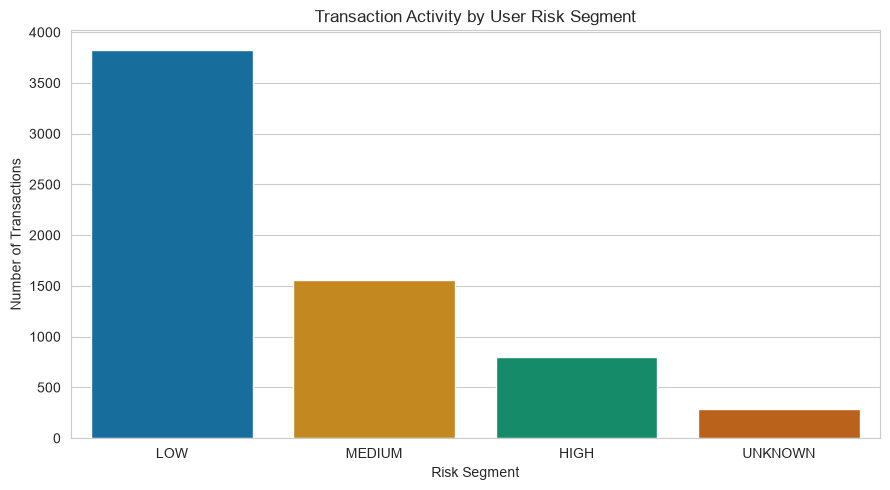

In [36]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=risk_transaction_summary,
    x="risk_segment",
    y="transaction_count",
    palette="colorblind"
)

plt.title("Transaction Activity by User Risk Segment")
plt.xlabel("Risk Segment")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

## Fraud-Oriented Analysis

### High-risk Users with Transaction Activity

In [37]:
high_risk_users = (
    transaction_risk[
        transaction_risk["risk_segment"] == "HIGH"
    ]
    .groupby("user_id")
    .agg(
        transaction_count=("txn_id", "count"),
        total_amount=("amount", "sum"),
        average_amount=("amount", "mean"),
        failed_transactions=(
            "status",
            lambda x: (x == "FAILED").sum()
        )
    )
    .reset_index()
    .sort_values(
        ["transaction_count", "total_amount"],
        ascending=False
    )
)

high_risk_users.head(15)

,user_id,transaction_count,total_amount,average_amount,failed_transactions
462,USR66152,3,53503.03,17834.343333,0
331,USR50470,3,26940.48,8980.160000,0
408,USR59734,2,45387.50,22693.750000,0
319,USR48697,2,44170.64,22085.320000,1
177,USR32494,2,40724.18,20362.090000,0
210,USR35487,2,39074.44,19537.220000,0
376,USR55182,2,38258.90,19129.450000,0
712,USR99619,2,37774.94,18887.470000,0
543,USR77173,2,37473.05,18736.525000,0
403,USR59090,2,34634.72,17317.360000,1


### High-risk Users with Chargebacks

In [38]:
user_chargebacks = (
    chargebacks
    .groupby("user_id")
    .agg(
        chargeback_count=("complaint_id", "count"),
        disputed_amount=("disputed_amount", "sum")
    )
    .reset_index()
)

high_risk_user_analysis = high_risk_users.merge(
    user_chargebacks,
    on="user_id",
    how="left"
)

high_risk_user_analysis["chargeback_count"] = (
    high_risk_user_analysis["chargeback_count"]
    .fillna(0)
)

high_risk_user_analysis["disputed_amount"] = (
    high_risk_user_analysis["disputed_amount"]
    .fillna(0)
)

high_risk_user_analysis = (
    high_risk_user_analysis
    .sort_values(
        ["chargeback_count", "total_amount"],
        ascending=False
    )
)

high_risk_user_analysis.head(15)

,user_id,transaction_count,total_amount,average_amount,failed_transactions,chargeback_count,disputed_amount
157,USR24926,1,21758.89,21758.89,0,7.0,26995.72
31,USR90528,2,25142.96,12571.48,0,1.0,215.00
88,USR73167,1,24905.65,24905.65,0,1.0,1257.85
145,USR79707,1,22331.23,22331.23,0,1.0,2121.87
177,USR91446,1,20792.68,20792.68,0,1.0,3582.55
201,USR93535,1,19815.57,19815.57,0,1.0,755.82
208,USR57427,1,19601.18,19601.18,0,1.0,543.72
52,USR82083,2,19083.16,9541.58,1,1.0,315.95
260,USR39576,1,17290.72,17290.72,0,1.0,0.00
316,USR44849,1,14944.75,14944.75,0,1.0,9759.54


### Users with Unusually Hhigh Transaction Activity

In [39]:
user_activity = (
    transactions
    .groupby("user_id")
    .agg(
        transaction_count=("txn_id", "count"),
        total_amount=("amount", "sum"),
        average_amount=("amount", "mean")
    )
    .reset_index()
    .sort_values(
        "transaction_count",
        ascending=False
    )
)

user_activity.head(15)

,user_id,transaction_count,total_amount,average_amount
10027,USR60393,5,52002.17,10400.434000
14728,USR84261,5,65457.39,13091.478000
9249,USR56391,4,46190.91,11547.727500
12212,USR71152,4,39633.34,13211.113333
13125,USR75989,4,51409.99,12852.497500
1052,USR15161,4,49813.31,12453.327500
11827,USR69151,4,65477.03,16369.257500
8912,USR54555,4,69477.83,17369.457500
1356,USR16553,4,44839.97,11209.992500
6739,USR43442,4,33212.74,8303.185000


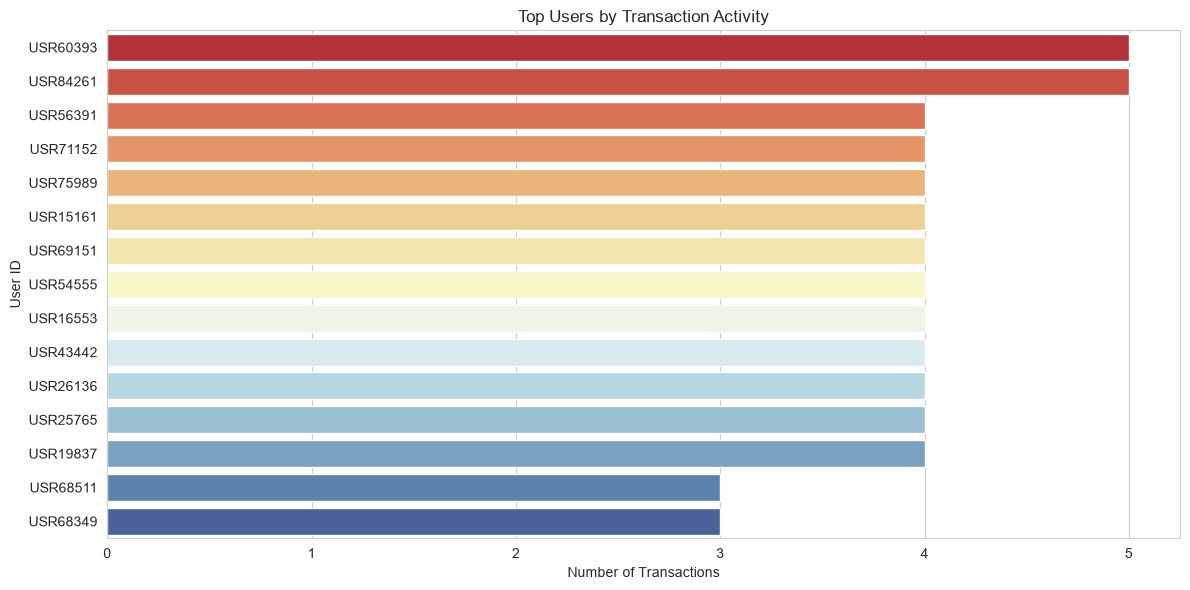

In [40]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=user_activity.head(15),
    y="user_id",
    x="transaction_count",
    palette="RdYlBu"
)

plt.title("Top Users by Transaction Activity")
plt.xlabel("Number of Transactions")
plt.ylabel("User ID")
plt.tight_layout()
plt.show()

### Merchant-Level Fraud Indicators

In [41]:
merchant_activity = (
    transaction_merchant
    .groupby("merchant_id")
    .agg(
        transaction_count=("txn_id", "count"),
        total_transaction_amount=("amount", "sum"),
        average_transaction_amount=("amount", "mean"),
        failed_transactions=(
            "status",
            lambda x: (x == "FAILED").sum()
        )
    )
    .reset_index()
)

In [42]:
merchant_chargebacks = (
    chargeback_merchant
    .groupby("merchant_id")
    .agg(
        chargeback_count=("complaint_id", "count"),
        disputed_amount=("disputed_amount", "sum")
    )
    .reset_index()
)

merchant_risk = merchant_activity.merge(
    merchant_chargebacks,
    on="merchant_id",
    how="left"
)

merchant_risk["chargeback_count"] = (
    merchant_risk["chargeback_count"].fillna(0)
)

merchant_risk["disputed_amount"] = (
    merchant_risk["disputed_amount"].fillna(0)
)

merchant_risk["chargeback_ratio"] = (
    merchant_risk["chargeback_count"]
    / merchant_risk["transaction_count"]
    * 100
)

merchant_risk = merchant_risk.sort_values(
    ["chargeback_count", "chargeback_ratio"],
    ascending=False
)

merchant_risk.head(15)

,merchant_id,transaction_count,total_transaction_amount,average_transaction_amount,failed_transactions,chargeback_count,disputed_amount,chargeback_ratio
3101,MCH4473,4,26185.15,6546.287500,0,48.0,124184.77,1200.000000
7430,MCH9291,3,20252.79,6750.930000,0,42.0,145622.83,1400.000000
6971,MCH8779,6,78407.96,13067.993333,0,34.0,75016.58,566.666667
1647,MCH2822,3,45585.77,15195.256667,0,33.0,91055.55,1100.000000
292,MCH1320,1,16705.45,16705.450000,0,30.0,47809.29,3000.000000
3640,MCH5076,2,28526.51,14263.255000,0,30.0,96715.22,1500.000000
4162,MCH5655,1,4198.80,4198.800000,0,29.0,70105.59,2900.000000
5199,MCH6810,2,47939.00,23969.500000,0,29.0,66519.64,1450.000000
4434,MCH5954,2,28731.99,14365.995000,0,28.0,136852.47,1400.000000
4458,MCH5980,2,25578.03,12789.015000,1,27.0,48196.30,1350.000000


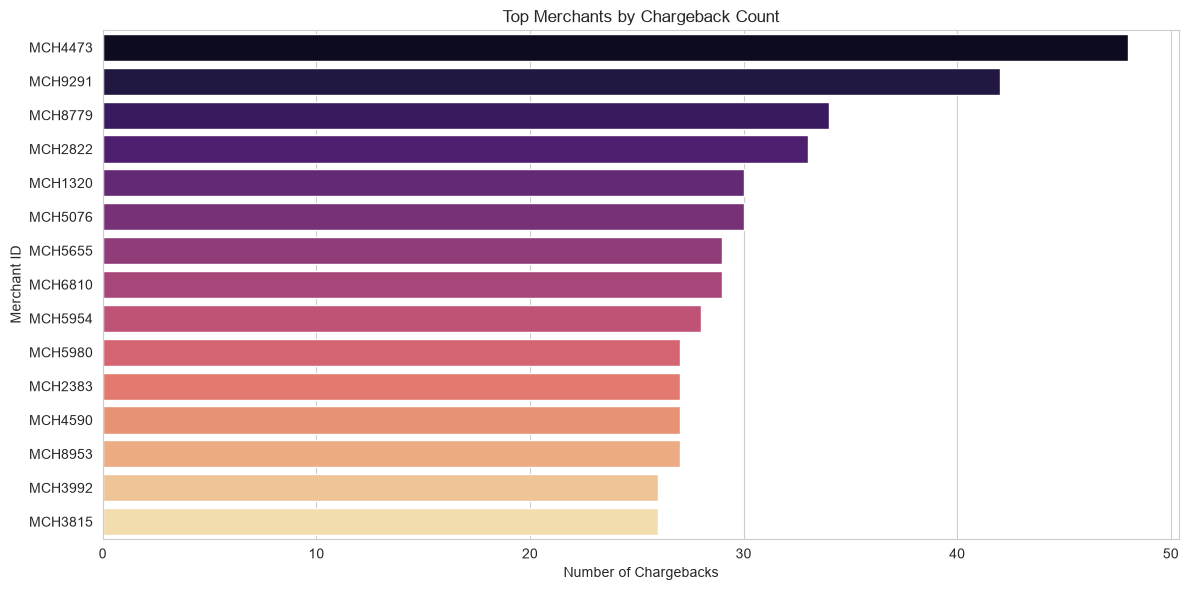

In [43]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=merchant_risk.head(15),
    y="merchant_id",
    x="chargeback_count",
    palette="magma"
)

plt.title("Top Merchants by Chargeback Count")
plt.xlabel("Number of Chargebacks")
plt.ylabel("Merchant ID")
plt.tight_layout()
plt.show()

## Transaction-Level Chargeback Analysis

### Match Chargebacks to Actual Transactions

In [44]:
chargeback_txn_analysis = chargebacks.merge(
    transactions[
        [
            "txn_id",
            "merchant_id",
            "user_id",
            "amount",
            "status"
        ]
    ],
    on="txn_id",
    how="inner",
    suffixes=("_chargeback", "_transaction")
)

print("Total chargebacks        :", len(chargebacks))
print("Chargebacks with matched transaction :", len(chargeback_txn_analysis))

Total chargebacks        : 2800
Chargebacks with matched transaction : 2607


### Unique Chargebacked Transactions

In [45]:
chargebacked_transactions = (
    chargeback_txn_analysis
    .groupby("txn_id")
    .agg(
        chargeback_count=("complaint_id", "count"),
        disputed_amount=("disputed_amount", "sum")
    )
    .reset_index()
)

print(
    "Unique transactions with chargebacks :",
    len(chargebacked_transactions)
)

Unique transactions with chargebacks : 2451


### Add Merchant Category

In [46]:
chargebacked_transactions = chargebacked_transactions.merge(
    transactions[
        [
            "txn_id",
            "merchant_id"
        ]
    ].drop_duplicates("txn_id"),
    on="txn_id",
    how="left",
    validate="one_to_one"
)

chargebacked_transactions = chargebacked_transactions.merge(
    merchant_lookup[
        [
            "merchant_id",
            "merchant_category"
        ]
    ],
    on="merchant_id",
    how="left",
    validate="many_to_one"
)

### Correct Category-Level Chargeback Rate

In [47]:
category_transactions = (
    transactions
    .merge(
        merchant_lookup[
            [
                "merchant_id",
                "merchant_category"
            ]
        ],
        on="merchant_id",
        how="left",
        validate="many_to_one"
    )
    .groupby("merchant_category", dropna=False)
    .agg(
        transaction_count=("txn_id", "nunique"),
        transaction_amount=("amount", "sum")
    )
    .reset_index()
)

category_chargebacked_txns = (
    chargebacked_transactions
    .groupby("merchant_category", dropna=False)
    .agg(
        chargebacked_transaction_count=("txn_id", "nunique"),
        disputed_amount=("disputed_amount", "sum")
    )
    .reset_index()
)

category_chargeback_rate = category_transactions.merge(
    category_chargebacked_txns,
    on="merchant_category",
    how="left"
)

category_chargeback_rate[
    "chargebacked_transaction_count"
] = category_chargeback_rate[
    "chargebacked_transaction_count"
].fillna(0)

category_chargeback_rate[
    "disputed_amount"
] = category_chargeback_rate[
    "disputed_amount"
].fillna(0)

category_chargeback_rate["chargeback_rate"] = (
    category_chargeback_rate["chargebacked_transaction_count"]
    / category_chargeback_rate["transaction_count"]
    * 100
)

category_chargeback_rate = (
    category_chargeback_rate
    .sort_values("chargeback_rate", ascending=False)
)

category_chargeback_rate

,merchant_category,transaction_count,transaction_amount,chargebacked_transaction_count,disputed_amount,chargeback_rate
11,Travel,137,1.686457e+06,20,32503.68,14.598540
8,Retail,242,3.089158e+06,34,108416.46,14.049587
0,Books & Stationery,1206,1.477250e+07,161,454081.86,13.349917
9,Telecom,766,9.363568e+06,102,309948.46,13.315927
7,Other,815,9.856613e+06,108,255283.26,13.251534
4,Grocery,947,1.166558e+07,122,374092.82,12.882788
10,Transport,632,7.827375e+06,79,185110.02,12.500000
12,<NA>,10369,1.267726e+08,1257,3671961.41,12.122673
1,Clothing,1276,1.557171e+07,154,386315.58,12.068966
3,Food Services,964,1.170132e+07,115,287144.65,11.929461


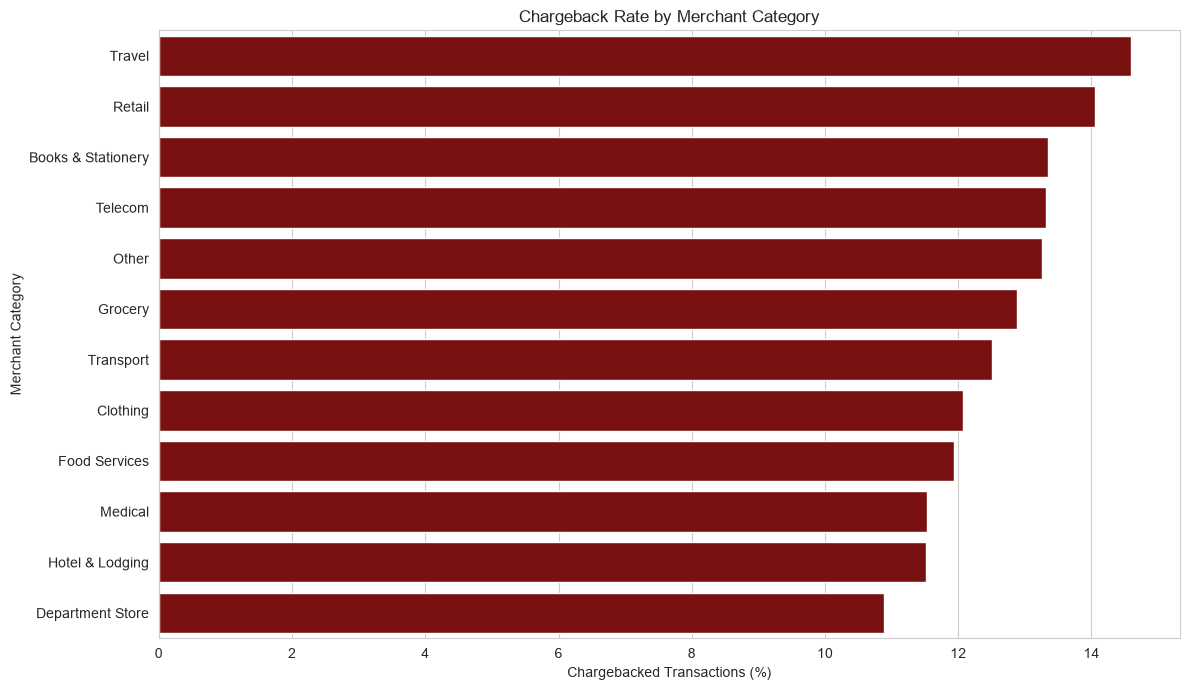

In [48]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=category_chargeback_rate,
    y="merchant_category",
    x="chargeback_rate",
    color="darkred",
)

plt.title("Chargeback Rate by Merchant Category")
plt.xlabel("Chargebacked Transactions (%)")
plt.ylabel("Merchant Category")
plt.tight_layout()
plt.show()

## Suspicious User Analysis

### User-Level Transaction Metrics

In [50]:
user_transaction_metrics = (
    transactions
    .groupby("user_id")
    .agg(
        transaction_count=("txn_id", "count"),
        total_transaction_amount=("amount", "sum"),
        average_transaction_amount=("amount", "mean"),
        failed_transaction_count=(
            "status",
            lambda x: (x == "FAILED").sum()
        )
    )
    .reset_index()
)

user_transaction_metrics

,user_id,transaction_count,total_transaction_amount,average_transaction_amount,failed_transaction_count
0,USR10001,1,1720.78,1720.780,1
1,USR10006,1,8445.34,8445.340,0
2,USR10007,2,26773.33,13386.665,0
3,USR10011,1,8691.46,8691.460,0
4,USR10012,1,11874.48,11874.480,0
...,...,...,...,...,...
17873,USR99967,1,2008.76,2008.760,0
17874,USR99972,1,14433.90,14433.900,0
17875,USR99979,1,21984.00,21984.000,0
17876,USR99996,1,14143.45,14143.450,0


### Chargeback Behavior

In [51]:
user_chargeback_metrics = (
    chargebacks
    .groupby("user_id")
    .agg(
        chargeback_count=("complaint_id", "count"),
        disputed_amount=("disputed_amount", "sum")
    )
    .reset_index()
)

user_risk_analysis = user_transaction_metrics.merge(
    user_chargeback_metrics,
    on="user_id",
    how="left"
)

user_risk_analysis["chargeback_count"] = (
    user_risk_analysis["chargeback_count"].fillna(0)
)

user_risk_analysis["disputed_amount"] = (
    user_risk_analysis["disputed_amount"].fillna(0)
)

### KYC Risk

In [52]:
user_risk_analysis = user_risk_analysis.merge(
    kyc_lookup[
        [
            "user_id",
            "risk_segment",
            "kyc_status"
        ]
    ],
    on="user_id",
    how="left",
    validate="one_to_one"
)

### Exploratory Risk Indicators

In [53]:
user_risk_analysis["has_chargeback"] = (
    user_risk_analysis["chargeback_count"] > 0
)

user_risk_analysis["high_failure_activity"] = (
    user_risk_analysis["failed_transaction_count"] >= 2
)

user_risk_analysis["high_transaction_activity"] = (
    user_risk_analysis["transaction_count"]
    >= user_risk_analysis["transaction_count"].quantile(0.95)
)

user_risk_analysis["high_risk_kyc"] = (
    user_risk_analysis["risk_segment"] == "HIGH"
)

user_risk_analysis["risk_signal_count"] = (
    user_risk_analysis[
        [
            "has_chargeback",
            "high_failure_activity",
            "high_transaction_activity",
            "high_risk_kyc"
        ]
    ]
    .sum(axis=1)
)

user_risk_analysis = user_risk_analysis.sort_values(
    [
        "risk_signal_count",
        "chargeback_count",
        "disputed_amount",
        "transaction_count"
    ],
    ascending=False
)

user_risk_analysis.head(20)

,user_id,transaction_count,total_transaction_amount,average_transaction_amount,failed_transaction_count,chargeback_count,disputed_amount,risk_segment,kyc_status,has_chargeback,high_failure_activity,high_transaction_activity,high_risk_kyc,risk_signal_count
14303,USR82083,2,19083.16,9541.580000,1,1.0,315.95,HIGH,VERIFIED,True,False,True,True,3
16054,USR90528,2,25142.96,12571.480000,0,1.0,215.00,HIGH,VERIFIED,True,False,True,True,3
10417,USR62254,3,40821.56,13607.186667,0,11.0,25002.64,LOW,VERIFIED,True,False,True,False,2
3013,USR24926,1,21758.89,21758.890000,0,7.0,26995.72,HIGH,VERIFIED,True,False,False,True,2
2077,USR20310,2,26692.72,13346.360000,1,4.0,14684.49,LOW,VERIFIED,True,False,True,False,2
14851,USR84844,3,55934.76,18644.920000,1,3.0,13167.18,LOW,VERIFIED,True,False,True,False,2
11670,USR68349,3,30640.86,10213.620000,0,2.0,3196.54,<NA>,<NA>,True,False,True,<NA>,2
2552,USR22598,2,32986.07,16493.035000,0,1.0,15201.89,<NA>,<NA>,True,False,True,<NA>,2
13673,USR79046,1,10907.40,10907.400000,0,1.0,12334.00,HIGH,VERIFIED,True,False,False,True,2
9851,USR59482,2,10602.90,5301.450000,1,1.0,12115.08,LOW,VERIFIED,True,False,True,False,2


### Users with Multiple Risk Signals

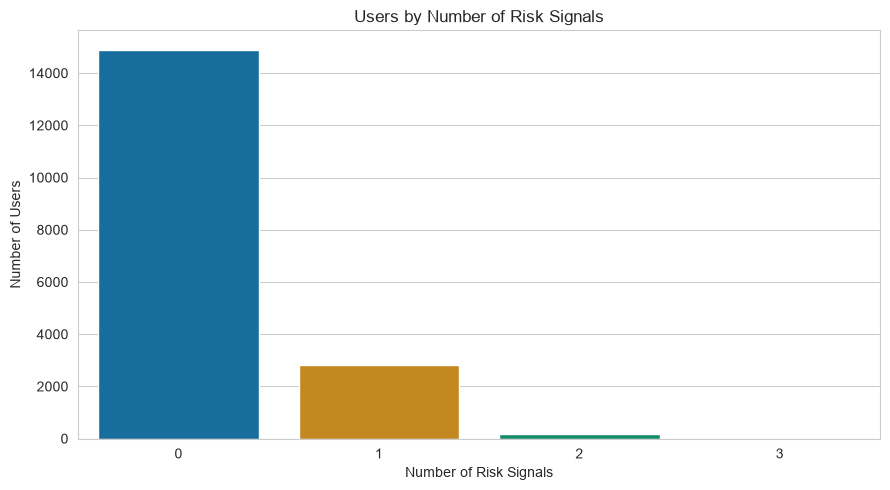

In [57]:
signal_summary = (
    user_risk_analysis
    .groupby("risk_signal_count")
    .size()
    .reset_index(name="user_count")
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=signal_summary,
    x="risk_signal_count",
    y="user_count",
    palette="colorblind"
)

plt.title("Users by Number of Risk Signals")
plt.xlabel("Number of Risk Signals")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()

### Top potentially suspicious users

In [58]:
user_risk_analysis[
    [
        "user_id",
        "transaction_count",
        "total_transaction_amount",
        "failed_transaction_count",
        "chargeback_count",
        "disputed_amount",
        "risk_segment",
        "kyc_status",
        "risk_signal_count"
    ]
].head(20)

,user_id,transaction_count,total_transaction_amount,failed_transaction_count,chargeback_count,disputed_amount,risk_segment,kyc_status,risk_signal_count
14303,USR82083,2,19083.16,1,1.0,315.95,HIGH,VERIFIED,3
16054,USR90528,2,25142.96,0,1.0,215.00,HIGH,VERIFIED,3
10417,USR62254,3,40821.56,0,11.0,25002.64,LOW,VERIFIED,2
3013,USR24926,1,21758.89,0,7.0,26995.72,HIGH,VERIFIED,2
2077,USR20310,2,26692.72,1,4.0,14684.49,LOW,VERIFIED,2
14851,USR84844,3,55934.76,1,3.0,13167.18,LOW,VERIFIED,2
11670,USR68349,3,30640.86,0,2.0,3196.54,<NA>,<NA>,2
2552,USR22598,2,32986.07,0,1.0,15201.89,<NA>,<NA>,2
13673,USR79046,1,10907.40,0,1.0,12334.00,HIGH,VERIFIED,2
9851,USR59482,2,10602.90,1,1.0,12115.08,LOW,VERIFIED,2
